# Tutorial of *Flow Matching for Applied Mathematicians* : Observation of the rectification process

This notebook enables the reproduction of several figures from the paper *Flow Matching for Applied Mathematicians*. It focuses on the rectification process. It can also be easily adapted as an introductory tutorial for educational purposes. We consider now the setting of the generalized flow matching where

# Packages and illustrations

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from sklearn.datasets import make_moons,make_blobs
from tqdm import tqdm

In [2]:
def gaussian_contour(mean, cov, ax=None, levels=[.5,1,1.5,2], n_points=200, **kwargs):
    """
    Plots contour lines of a two-dimensional Gaussian distribution defined by 
    the given mean and covariance matrix.
    """
    if ax is None:
        fig, ax = plt.subplots()
    
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    stds = np.sqrt(np.diag(cov))
    x = np.linspace(mean[0]-4*stds[0], mean[0]+4*stds[0], n_points)
    y = np.linspace(mean[1]-4*stds[1], mean[1]+4*stds[1], n_points)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    inv_cov = np.linalg.inv(cov)
    diff = pos - mean
    mahal = np.einsum('...i,ij,...j->...', diff, inv_cov, diff)

    cs = ax.contour(X, Y, mahal, levels=[l**2 for l in levels], **kwargs)

    ax.plot(mean[0], mean[1], 'o', color=kwargs.get('colors'))

    return cs, ax




def euler_solver(x0,v,n_steps=100,T=1,only_last_it=False) :
    """
    Adapted for torch.
    Solves an ordinary differential equation using the explicit Euler method.
    Starting from an initial state `x0`, the solver advances the solution over
    the time interval [0, T] using `n_steps` uniformly spaced steps. The vector
    field is provided as a Python function `v(t, x)`. The function returns an
    array containing the complete trajectory, including the initial state.
    """
    times = torch.linspace(0,T,n_steps+1)
    t = times[0]
    xt = x0
    if not only_last_it :
        xts = torch.zeros((n_steps+1, *x0.shape))
        xts[0] = xt.clone()
    for i in range(n_steps) :
        dt = times[i+1]-times[i]
        xt = xt+dt*v(torch.full((xt.shape[0],), t),xt)
        if not only_last_it :
            xts[i+1] = xt.clone()
        t += dt
    if not only_last_it :
        return xts
    else :
        return xt

In [3]:
#We use a consistent color palette throughout the notebook, defined below.
color_source = '#648FFF'
color_target = '#DC267F'
color_trajectories = '#323232'

cmap_path = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_path",
    [color_source, color_target]
)

# Illustration of the generalization through a learned velocity

We train a flow matching model for an independent coupling $(X_0, X_1)$, where $X_0 \sim \mathcal{N}(0, I)$ can be sampled infinitely, and $X_1$ is given as a finite collection of samples.

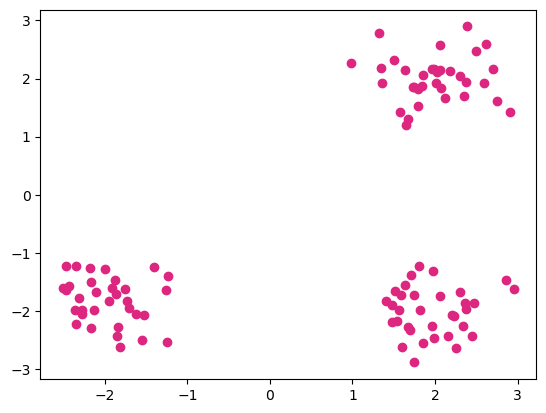

In [4]:
# Construction of X1
dim = 2
n_samples = 10**2

centers = [[2, 2], [-2, -2], [2, -2]]
X, _ = make_blobs(n_samples=n_samples, centers=centers,cluster_std=0.4, n_features=dim,random_state=0)

dataset = torch.tensor(X, dtype=torch.float32)
plt.scatter(dataset[:,0],dataset[:,1],color=color_target)
x1 = dataset.clone()

We parametrize a very simple neural network for 2D examples.

In [5]:
class VelocityField(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim+1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, dim)
        )
    def forward(self, t, x):
        t = t.view(-1,1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

Below, it is the training by minimizing the Flow Matching loss

$$
L(\theta) = \int_0^1 \mathbb{E}\| v^\theta (t,X_t) - (X_1 - X_0)\|^2dt
$$

In [6]:
# --- Training parameters---
n_epochs = 10**4
lr = 1e-3
batch_size = 100
model = VelocityField(dim)
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## Training
for epoch in tqdm(range(n_epochs)):
    perm = torch.randperm(x1.size(0))
    
    for i in range(0, x1.size(0), batch_size):
        batch_x0 = torch.randn(batch_size,dim)
        idx = perm[i : i + batch_size]
        batch_x1 = x1[idx]
        
        t = torch.rand(batch_size)
        
        xt = (1-t).view(-1,1)*batch_x0 + t.view(-1,1)*batch_x1
        
        v_target = batch_x1 - batch_x0
        v_pred = model(t, xt)
        
        loss = loss_fn(v_pred, v_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    


100%|███████████████████████████████████| 10000/10000 [00:04<00:00, 2342.39it/s]


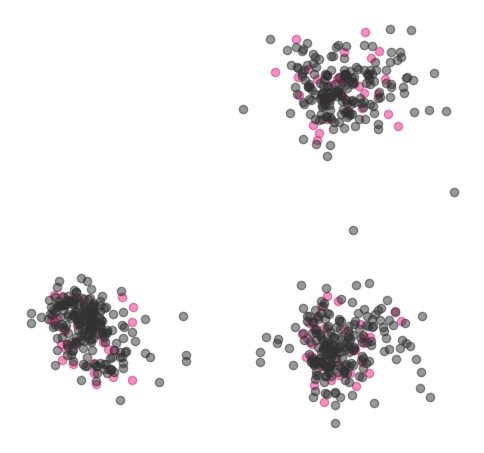

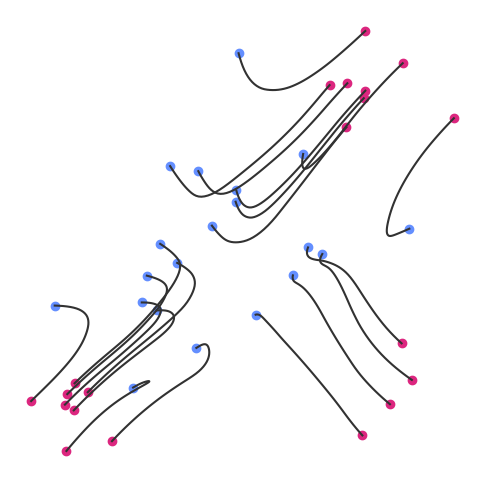

In [7]:
n_traj = 600
x0 = torch.randn(n_traj,2)
steps = 50

xts = euler_solver(x0,model,n_steps=steps)

x1_theta = xts[-1].detach().numpy()
x0_np = x0.detach().numpy()
x1_np = x1.detach().numpy()

plt.figure(figsize=(6,6))
plt.scatter(x1_np[:,0], x1_np[:,1], alpha=0.5, color=color_target)
plt.scatter(x1_theta[:,0], x1_theta[:,1], alpha=0.5,color=color_trajectories)
plt.axis('equal')
plt.axis('off')
#plt.legend()
plt.axis('scaled')
plt.show()

plt.figure(figsize=(6,6))
xts_np = xts.detach().numpy()
times = np.linspace(0,1,steps+1)
nb_traj_plot = 20
for k in range(nb_traj_plot):
    plt.plot(xts_np[:,k,0],xts_np[:,k,1],color=color_trajectories)
    plt.scatter([xts_np[0,k,0]],[xts_np[0,k,1]],color=color_source)
    plt.scatter([xts_np[-1,k,0]],[xts_np[-1,k,1]],color=color_target)
    plt.axis('off')



# Rectification

Given the velocity $v^\theta$ learned previously, the rectification process consists in training a new velocity, not with the former independent initial coupling $(X_0, X_1)$, but with $(Z_0, Z_1)$, where $Z_0 \sim \mathcal{N}(0,I)$ and $Z_1$ is obtained as $Z_1 = \varphi_1(X_0)$, with $\varphi$ the flow associated with $v^\theta$.

In [8]:
# --- Training parameters---
n_epochs = 10**4
lr = 1e-3
batch_size = 100
model_rectification = VelocityField(dim)
optimizer = optim.Adam(model_rectification.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## Training
for epoch in tqdm(range(n_epochs)):
    perm = torch.randperm(x1.size(0))
    
    for i in range(0, x1.size(0), batch_size):
        batch_x0 = torch.randn(batch_size,dim)
        idx = perm[i : i + batch_size]
        batch_x1 = euler_solver(batch_x0,model,n_steps=steps,only_last_it=True)
        
        t = torch.rand(batch_size)
        
        xt = (1-t).view(-1,1)*batch_x0 + t.view(-1,1)*batch_x1
        
        v_target = batch_x1 - batch_x0
        v_pred = model_rectification(t, xt)
        
        loss = loss_fn(v_pred, v_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    


100%|████████████████████████████████████| 10000/10000 [01:31<00:00, 108.79it/s]


Observe that the trajectories are now much straighter.

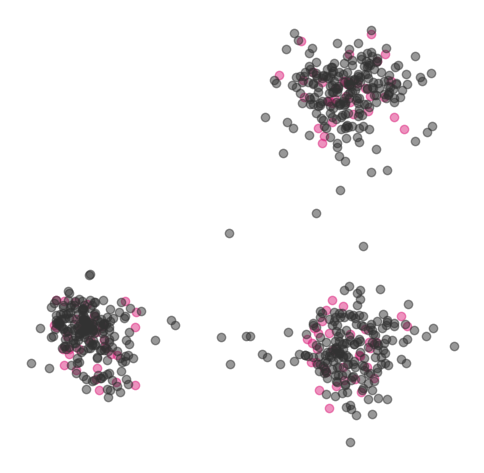

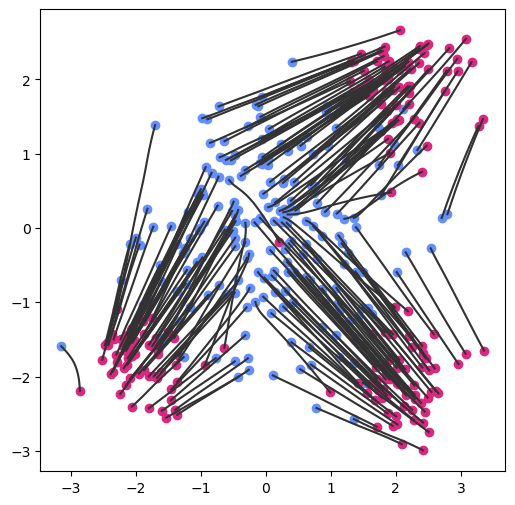

In [9]:
n_traj = 600
x0 = torch.randn(n_traj,2)
steps = 50

xts = euler_solver(x0,model_rectification,n_steps=steps)

x1_theta = xts[-1].detach().numpy()
x0_np = x0.detach().numpy()
x1_np = x1.detach().numpy()

plt.figure(figsize=(6,6))
plt.scatter(x1_np[:,0], x1_np[:,1], alpha=0.5, color=color_target)
plt.scatter(x1_theta[:,0], x1_theta[:,1], alpha=0.5,color=color_trajectories)
plt.axis('equal')
plt.axis('off')
#plt.legend()
plt.axis('scaled')
plt.show()

plt.figure(figsize=(6,6))
xts_np = xts.detach().numpy()
times = np.linspace(0,1,steps+1)[::2]
nb_traj_plot = 200
for k in range(nb_traj_plot):
    plt.plot(xts_np[:,k,0],xts_np[:,k,1],color=color_trajectories)
    plt.scatter([xts_np[0,k,0]],[xts_np[0,k,1]],color=color_source)
    plt.scatter([xts_np[-1,k,0]],[xts_np[-1,k,1]],color=color_target)

